# Assignment Number 2 : Iris Dataset

## 📘 About the Dataset
The **Iris dataset** is a toy dataset in machine learning,
It contains measurements of **150 iris flowers** across three species:
- Setosa
- Versicolor
- Virginica  

The goal is to classify the species based on these features.
---

##  What We Have Done
1. **Data Loading & Inspection**  
2. **Data Visualization (Matplotlib only)**    
3. **Model Training**  
4. **Model Evaluation**     
---

## 🤖 Algorithm Used: Multi-Layer Perceptron (MLP)
The **MLPClassifier** is a feedforward neural network model.  
- It consists of input, hidden, and output layers.  
- Each neuron applies a weighted sum followed by a non-linear activation function.  
- The model is trained using **backpropagation** and gradient descent to minimize loss.  

In our MLP model, we used the **ReLU (Rectified Linear Unit)** activation function for the hidden layers.  
- ReLU is defined as: \( f(x) = \max(0, x) \).  
- It introduces non-linearity, allowing the network to learn complex patterns.



In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# Map numeric labels to species names
df['species'] = df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# Display first 10 rows
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [ ]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


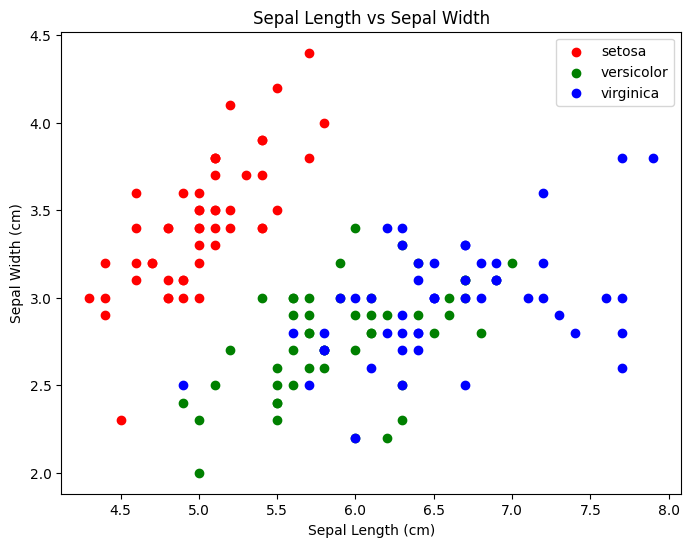

In [ ]:
colors = {'setosa':'red', 'versicolor':'green', 'virginica':'blue'}

plt.figure(figsize=(8,6))
for species in df['species'].unique():
    subset = df[df['species'] == species]
    plt.scatter(subset['sepal length (cm)'], subset['sepal width (cm)'],
                c=colors[species], label=species)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Sepal Length vs Sepal Width')
plt.legend()
plt.show()

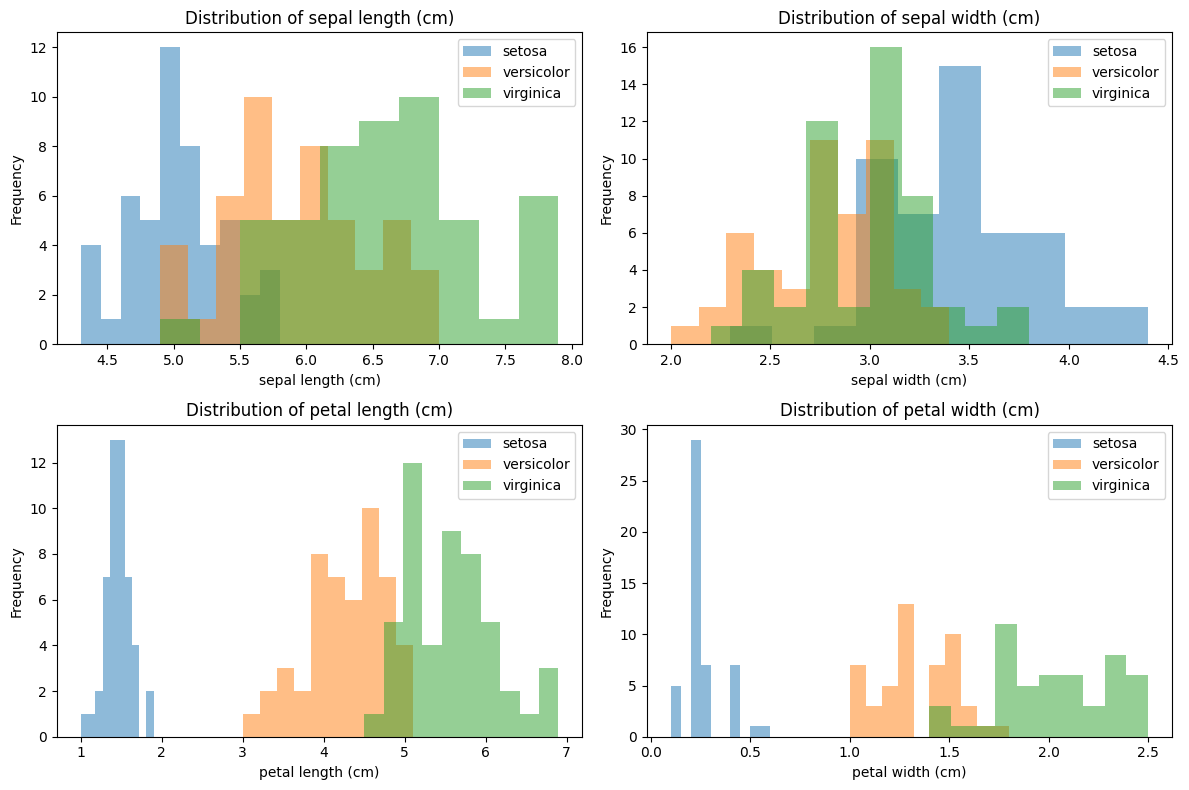

In [ ]:
plt.figure(figsize=(12,8))
for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(2,2,i)
    for species in df['species'].unique():
        subset = df[df['species'] == species]
        plt.hist(subset[column], alpha=0.5, label=species)
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')
    plt.legend()
plt.tight_layout()
plt.show()

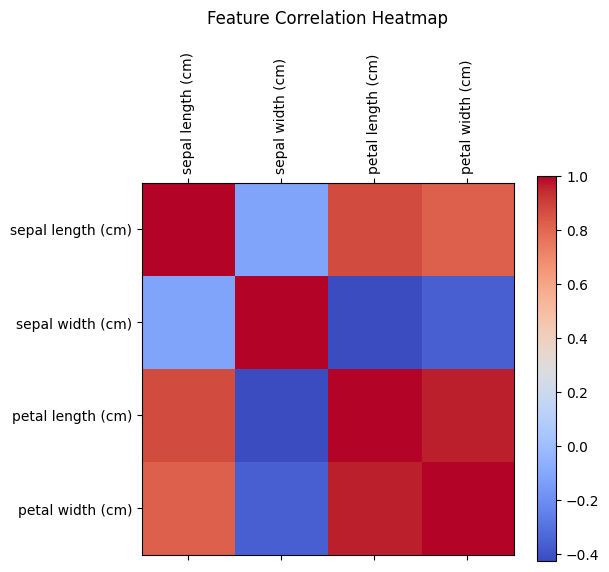

In [ ]:
corr = df.drop("species", axis=1).corr()

fig, ax = plt.subplots(figsize=(6,5))
cax = ax.matshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(cax)
plt.title("Feature Correlation Heatmap", pad=20)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop("species", axis=1)
y = df["species"]

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
from sklearn.neural_network import MLPClassifier

# Initialize MLP model
mlp = MLPClassifier(
  hidden_layer_sizes=(10, 10),   # two hidden layers with 10 neurons each
  activation='relu',             # specify ReLU activation
  max_iter=1000,
  random_state=42
)

# Train the model
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)

Accuracy: 0.9777777777777777

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.94      1.00      0.97        15
   virginica       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



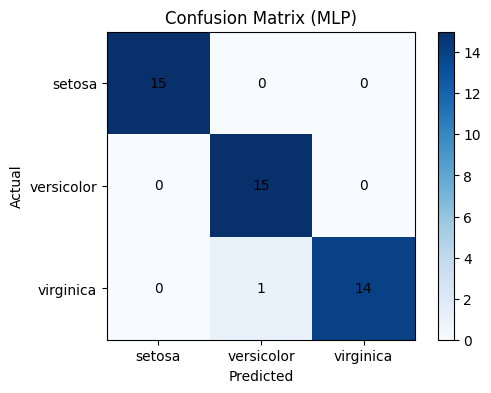

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

# Predictions
y_pred = mlp.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Visualization (Matplotlib only)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,4))
im = ax.imshow(cm, cmap="Blues")

# Show labels
ax.set_xticks(np.arange(len(mlp.classes_)))
ax.set_yticks(np.arange(len(mlp.classes_)))
ax.set_xticklabels(mlp.classes_)
ax.set_yticklabels(mlp.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (MLP)")

# Annotate cells
for i in range(len(mlp.classes_)):
    for j in range(len(mlp.classes_)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im)
plt.show()

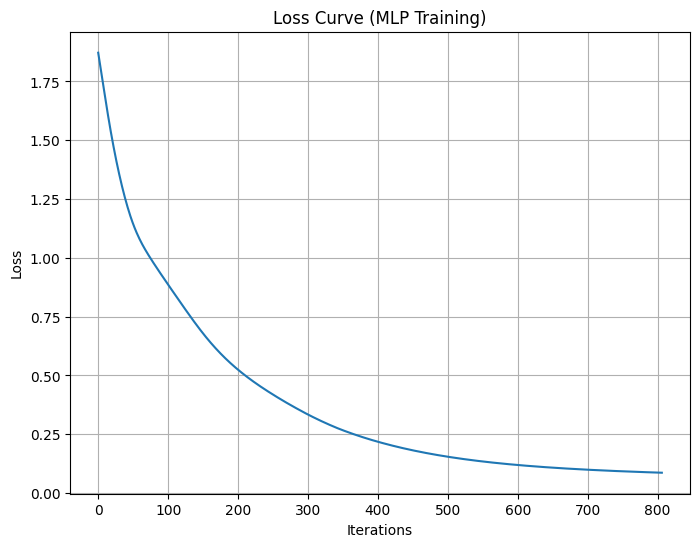

In [ ]:
plt.figure(figsize=(8,6))
plt.plot(mlp.loss_curve_)
plt.title("Loss Curve (MLP Training)")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()